# VOLTA · 03 — Battery optimizer (the money module)

**100 MW / 200 MWh · 88% round-trip · 1 cycle/day · Spain 2015–2018**

Phase 2 gave us a 24h-ahead price. This notebook turns it into a charge/discharge schedule and a euro number.

1. **3A** Perfect-foresight LP — the *ceiling*. If we knew tomorrow's spot, what would the battery earn?
2. **3B** Realistic rolling day-ahead — schedule on **our** forecast, settle on realised spot. The gap is the cost of forecast error.
3. Economics — NPV / payback at 2018-era capex, plus a sensitivity table.

`src/optimizer.py` is the source of truth. Invariants live in `tests/test_optimizer.py`.


### How to run

Needs `data/processed/market.parquet` from notebook 01.

```bash
pip install -r requirements-dev.txt
jupyter notebook notebooks/03_dispatch.ipynb
```


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ROOT = Path.cwd()
if not (ROOT / "src" / "config.py").exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "config.py").exists():
            ROOT = p
            break
sys.path.insert(0, str(ROOT))

from src.config import MARKET_PARQUET, CACHE, BATTERY_CAPEX_EUR_PER_KWH, WACC, ASSET_LIFE_YEARS
from src.features import PRICE_FEATURES, build_feature_frame
from src.models import walk_forward_years
from src.optimizer import (
    DEFAULT_BATTERY, solve_day, settle, assert_invariants,
    backtest_daily, economics, with_battery,
)

FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

TEAL, AMBER, NAVY, SLATE, RED, GAS = "#0D9488", "#D97706", "#0F172A", "#64748B", "#DC2626", "#EA580C"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#E2E8F0", "axes.grid": True, "grid.color": "#F1F5F9",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "semibold",
    "figure.dpi": 120, "savefig.dpi": 160, "legend.frameon": False,
})


def savefig(fig, name):
    fig.savefig(FIG / name, bbox_inches="tight", facecolor="white")
    print("saved", (FIG / name).relative_to(ROOT))

print(DEFAULT_BATTERY)
print("capex assumption: €{:.0f}/kWh × {:.0f} MWh = €{:.1f}m".format(
    BATTERY_CAPEX_EUR_PER_KWH, DEFAULT_BATTERY.capacity_mwh,
    BATTERY_CAPEX_EUR_PER_KWH * DEFAULT_BATTERY.capacity_mwh / 1000,
))


BatteryParams(power_mw=100.0, capacity_mwh=200.0, round_trip=0.88, min_soc_pct=0.1, max_cycles_per_day=1.0, degradation_eur_per_mwh=3.0)
capex assumption: €350/kWh × 200 MWh = €70.0m


---
## 3A · Perfect-foresight LP (the ceiling)

One day, 24 (or 23/25) hours. Charge `c_t`, discharge `d_t`, SOC `E_t`.

| Constraint | Number |
|---|---|
| Power | 0 ≤ c, d ≤ **100 MW** |
| Energy | **20 MWh** ≤ E ≤ **200 MWh** (10% floor) |
| Physics | E_{t+1} = E_t + η c_t − d_t / η, η = √0.88 |
| Cyclic | E_end = E_start (don't drain the asset overnight as a trick) |
| Cycles | Σ d_t ≤ **200 MWh/day** (1 cycle) |
| Degradation | €3 per MWh discharged to the grid, inside the objective |

No binaries. Simultaneous charge+discharge is feasible and *never* optimal when η < 1 and prices > 0.


toy profit € 11494.9 cycles 1.0
charge hours [3, 4, 14]
discharge hours [8, 18, 19]


saved notebooks/figures/20_toy_dispatch.png


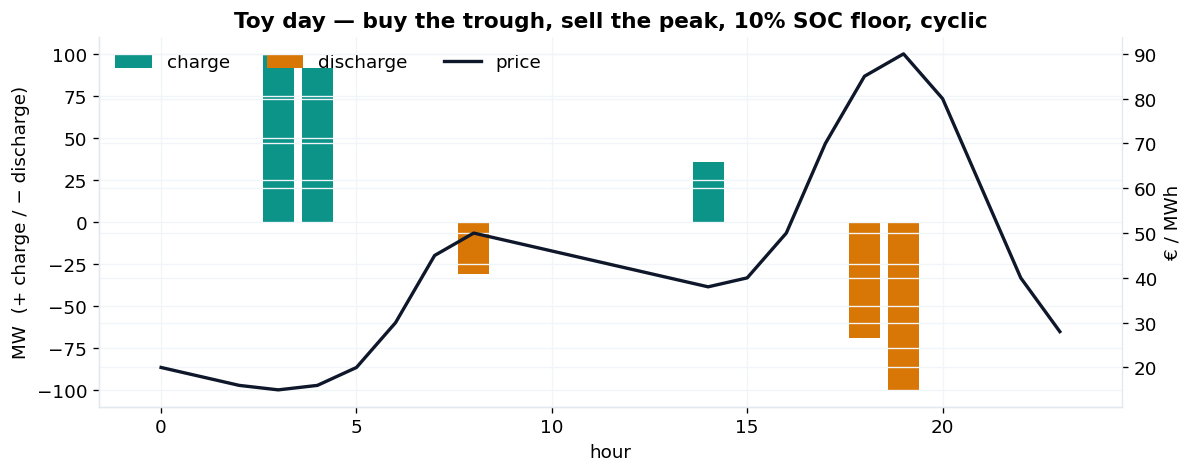

In [2]:
# Sanity: a made-up day. Cheap night, expensive evening.
toy_prices = np.array([20, 18, 16, 15, 16, 20, 30, 45, 50, 48, 46, 44,
                       42, 40, 38, 40, 50, 70, 85, 90, 80, 60, 40, 28], dtype=float)
toy = solve_day(toy_prices)
assert_invariants(toy)
print("toy profit €", round(toy.profit_eur, 1), "cycles", round(toy.discharge_mw.sum()/200, 2))
print("charge hours", np.where(toy.charge_mw > 1)[0].tolist())
print("discharge hours", np.where(toy.discharge_mw > 1)[0].tolist())

fig, ax1 = plt.subplots(figsize=(11, 4.0))
hours = np.arange(len(toy_prices))
ax1.bar(hours, toy.charge_mw, color=TEAL, label="charge", width=0.8)
ax1.bar(hours, -toy.discharge_mw, color=AMBER, label="discharge", width=0.8)
ax1.set_ylabel("MW  (+ charge / − discharge)")
ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color("#E2E8F0")
ax2.plot(hours, toy_prices, color=NAVY, lw=2, label="price")
ax2.set_ylabel("€ / MWh")
ax1.set_title("Toy day — buy the trough, sell the peak, 10% SOC floor, cyclic")
ax1.set_xlabel("hour")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left", ncol=3)
savefig(fig, "20_toy_dispatch.png")
plt.show()


**Assumption (efficiency).** Round-trip 88% is split equally, η_c = η_d = √0.88 ≈ 0.938. Interviews will ask; there is no better split in this dataset.


In [3]:
market = pd.read_parquet(MARKET_PARQUET)
spot = market["price_actual"].dropna()
print("spot", spot.index.min(), "→", spot.index.max(), "n=", len(spot))

perfect, hourly_p = backtest_daily(spot)
assert_invariants(solve_day(spot.iloc[:24].values))  # one more live check

yearly = perfect.groupby(perfect.index.year).agg(
    profit_eur=("profit_eur", "sum"),
    days=("profit_eur", "size"),
    hit_rate=("profit_eur", lambda s: (s > 0).mean()),
    mean_spread=("spread_eur", "mean"),
    mean_cycles=("cycles", "mean"),
)
yearly["eur_per_mw"] = yearly["profit_eur"] / DEFAULT_BATTERY.power_mw
display(yearly)
print("4-year total €{:,.0f}   mean year €{:,.0f}".format(
    perfect["profit_eur"].sum(), perfect["profit_eur"].sum() / 4,
))


spot 2015-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00 n= 35064


,profit_eur,days,hit_rate,mean_spread,mean_cycles,eur_per_mw
day,,,,,,
2015,"1,088,627.72",365,1.00,26.33,0.88,"10,886.28"
2016,"736,640.10",366,0.95,20.00,0.83,"7,366.40"
2017,"682,983.09",365,0.92,21.34,0.78,"6,829.83"
2018,"626,033.04",365,0.86,21.40,0.73,"6,260.33"


4-year total €3,134,284   mean year €783,571


### Six interesting days — SOC vs price


saved notebooks/figures/21_six_days.png


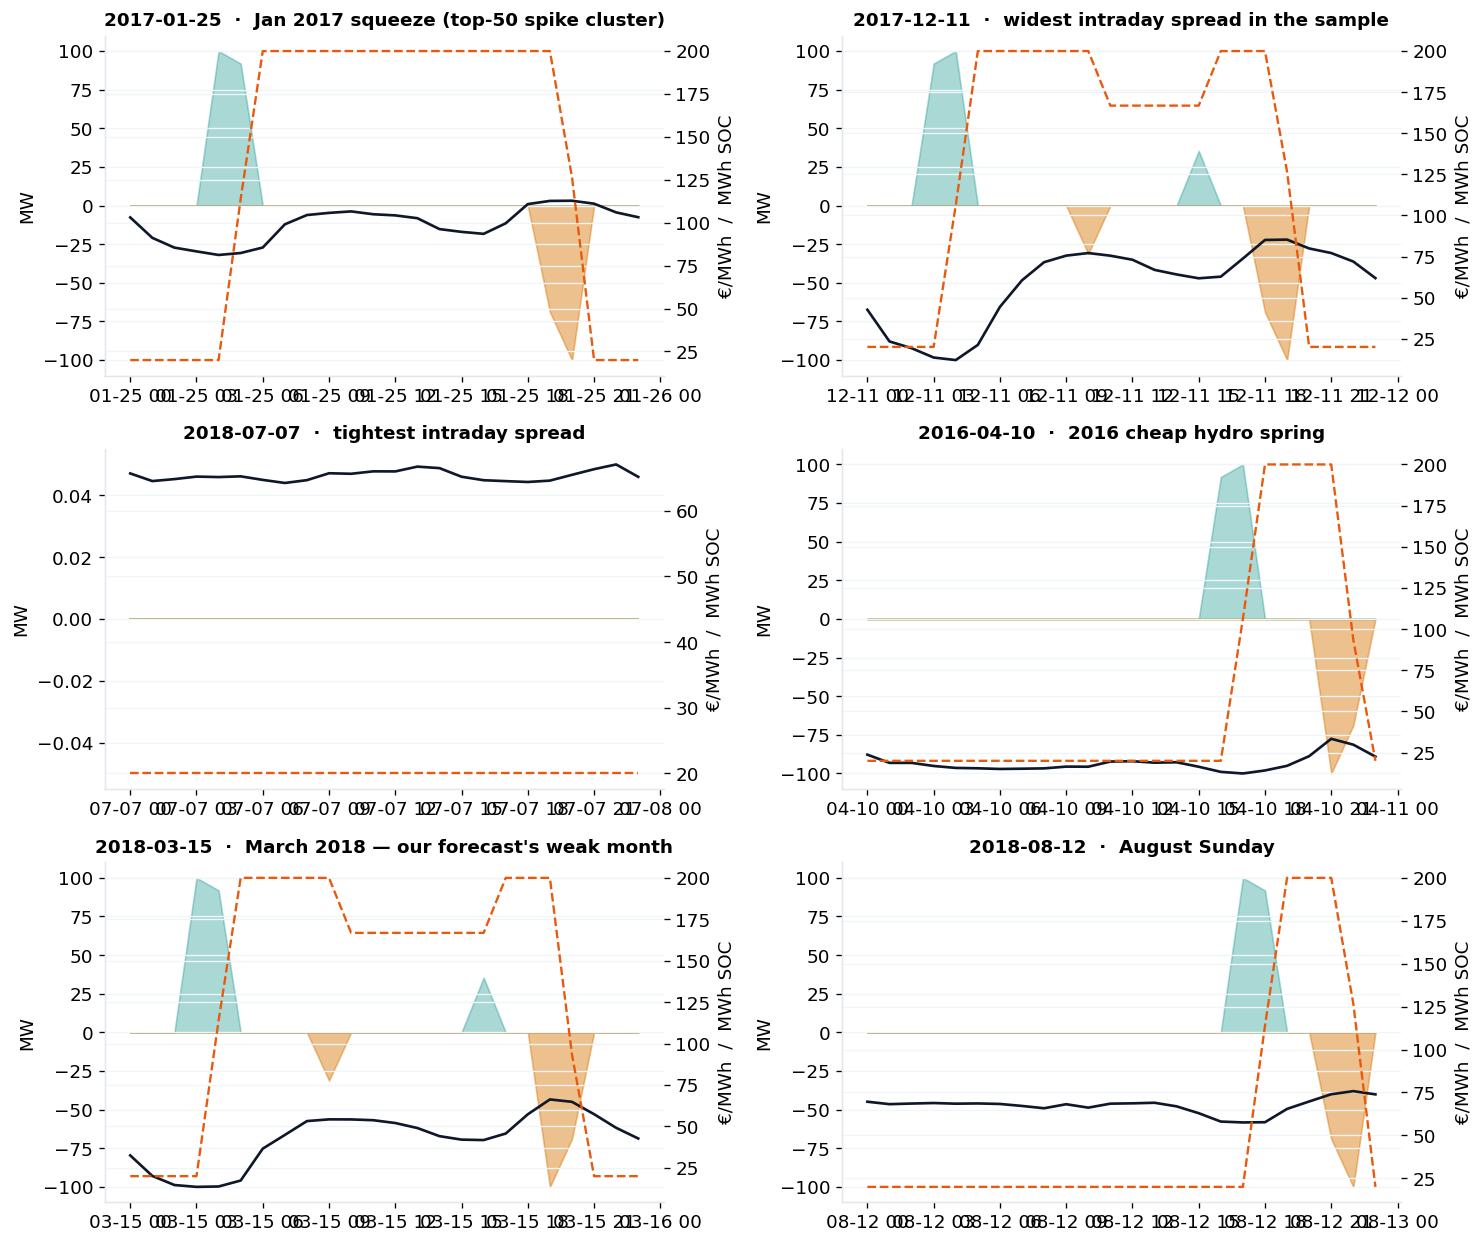

In [4]:
# pick days by story, not by cherry-picking profit
daily_spread = hourly_p.groupby(hourly_p.index.date)["price_actual"].agg(lambda s: s.max()-s.min())
wide = pd.Timestamp(daily_spread.idxmax())
tight = pd.Timestamp(daily_spread.idxmin())
picks = [
    (pd.Timestamp("2017-01-25"), "Jan 2017 squeeze (top-50 spike cluster)"),
    (wide, "widest intraday spread in the sample"),
    (tight, "tightest intraday spread"),
    (pd.Timestamp("2016-04-10"), "2016 cheap hydro spring"),
    (pd.Timestamp("2018-03-15"), "March 2018 — our forecast's weak month"),
    (pd.Timestamp("2018-08-12"), "August Sunday"),
]

fig, axes = plt.subplots(3, 2, figsize=(12.5, 10.5), sharex=False)
for ax, (day, title) in zip(axes.ravel(), picks):
    s = hourly_p.loc[str(day.date())]
    if len(s) == 0:
        ax.set_title(title + " (missing)")
        continue
    ax.fill_between(s.index, 0, s["charge_mw"], color=TEAL, alpha=0.35, label="charge")
    ax.fill_between(s.index, 0, -s["discharge_mw"], color=AMBER, alpha=0.45, label="discharge")
    ax2 = ax.twinx()
    ax2.plot(s.index, s["price_actual"], color=NAVY, lw=1.6)
    ax2.plot(s.index, s["soc_mwh"], color=GAS, lw=1.4, ls="--")
    ax2.set_ylabel("€/MWh  /  MWh SOC")
    ax.set_ylabel("MW")
    ax.set_title(f"{day.date()}  ·  {title}", fontsize=11)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
fig.tight_layout()
savefig(fig, "21_six_days.png")
plt.show()


**Insight.** The LP does the obvious thing, which is the point: it is a *ceiling*, not a strategy. On spike days it fills overnight and dumps 19:00–21:00. On tight-spread days it barely moves — degradation + round-trip eat a €5 spread. A 2-hour battery with a 1-cycle cap cannot harvest a morning *and* evening peak; it picks the fatter one.


saved notebooks/figures/22_perfect_pnl.png


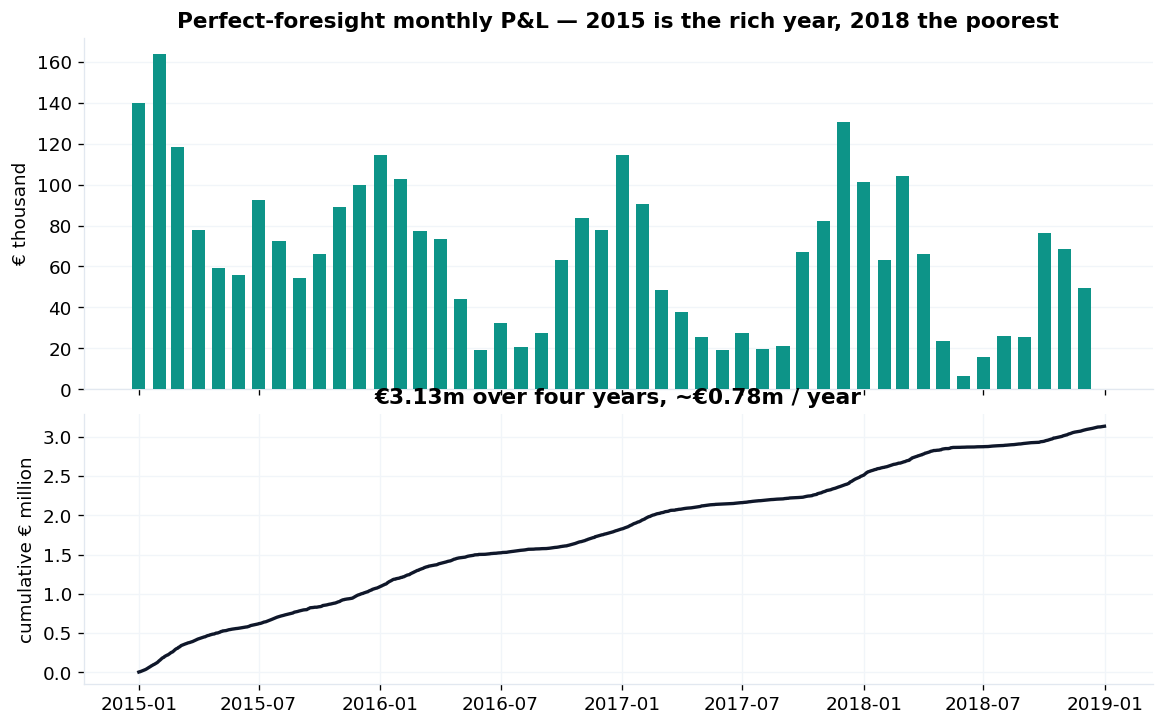

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.08})
monthly = perfect.resample("MS")["profit_eur"].sum()
axes[0].bar(monthly.index, monthly.values / 1000, width=20, color=TEAL, zorder=3)
axes[0].set_ylabel("€ thousand")
axes[0].set_title("Perfect-foresight monthly P&L — 2015 is the rich year, 2018 the poorest")
axes[0].set_axisbelow(True)
axes[0].xaxis.grid(False)

cum = perfect["profit_eur"].cumsum() / 1e6
axes[1].plot(cum.index, cum.values, color=NAVY, lw=2)
axes[1].set_ylabel("cumulative € million")
axes[1].set_title("€{:.2f}m over four years, ~€{:.2f}m / year".format(
    perfect["profit_eur"].sum()/1e6, perfect["profit_eur"].sum()/4e6,
))
savefig(fig, "22_perfect_pnl.png")
plt.show()


---
## 3B · Realistic: schedule on our forecast, settle on the market

For each day: solve the LP on the **24h-ahead forecast**, then apply that (c, d) to **realised** prices. SOC physics follow the schedule; euros follow the truth.

Forecasts are expanding-window XGBoost from Phase 2, years **2016–2018** (2015 is burn-in — not enough history to claim a model). 2015 stays perfect-foresight-only.


In [6]:
frame = build_feature_frame(market)
need = list(dict.fromkeys([*PRICE_FEATURES, "price_actual", "price_da"]))
model_df = frame[need].dropna()

print("building 2016–2018 walk-forward forecasts (36 monthly refits)…")
wf = walk_forward_years(model_df, PRICE_FEATURES, "price_actual", years=(2016, 2017, 2018))
print("wf", wf.index.min(), "→", wf.index.max(), "n=", len(wf))
wf_path = CACHE / "wf_forecasts_2016_2018.parquet"
wf.to_parquet(wf_path)
print("wrote", wf_path.relative_to(ROOT))


building 2016–2018 walk-forward forecasts (36 monthly refits)…


wf 2016-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00 n= 26304
wrote cache/wf_forecasts_2016_2018.parquet


In [7]:
spot_wf = spot.reindex(wf.index).dropna()
fc = wf["pred"].reindex(spot_wf.index)
tso = wf["tso"].reindex(spot_wf.index)

realistic, _ = backtest_daily(spot_wf, schedule_on=fc)
tso_bt, _ = backtest_daily(spot_wf, schedule_on=tso)
perfect_same, _ = backtest_daily(spot_wf)   # ceiling on the SAME hours (2016-18)

cmp = pd.DataFrame({
    "perfect": perfect_same.groupby(perfect_same.index.year)["profit_eur"].sum(),
    "VOLTA forecast": realistic.groupby(realistic.index.year)["profit_eur"].sum(),
    "TSO price_da": tso_bt.groupby(tso_bt.index.year)["profit_eur"].sum(),
})
cmp.loc["TOTAL"] = cmp.sum()
cmp["VOLTA / perfect"] = cmp["VOLTA forecast"] / cmp["perfect"]
cmp["TSO / perfect"] = cmp["TSO price_da"] / cmp["perfect"]
display(cmp)

gap = perfect_same["profit_eur"].sum() - realistic["profit_eur"].sum()
print("cost of forecast error 2016-18: €{:,.0f}  ({:.1%} of ceiling)".format(
    gap, gap / perfect_same["profit_eur"].sum(),
))
print("hit-rate perfect / VOLTA / TSO: {:.0%} / {:.0%} / {:.0%}".format(
    (perfect_same.profit_eur > 0).mean(),
    (realistic.profit_eur > 0).mean(),
    (tso_bt.profit_eur > 0).mean(),
))


,perfect,VOLTA forecast,TSO price_da,VOLTA / perfect,TSO / perfect
day,,,,,
2016,"736,640.10","594,693.02","500,041.40",0.81,0.68
2017,"682,983.09","564,689.92","441,056.43",0.83,0.65
2018,"626,033.04","477,349.09","373,219.37",0.76,0.60
TOTAL,"2,045,656.23","1,636,732.03","1,314,317.21",0.80,0.64


cost of forecast error 2016-18: €408,924  (20.0% of ceiling)
hit-rate perfect / VOLTA / TSO: 91% / 81% / 73%


saved notebooks/figures/23_perfect_vs_realistic.png


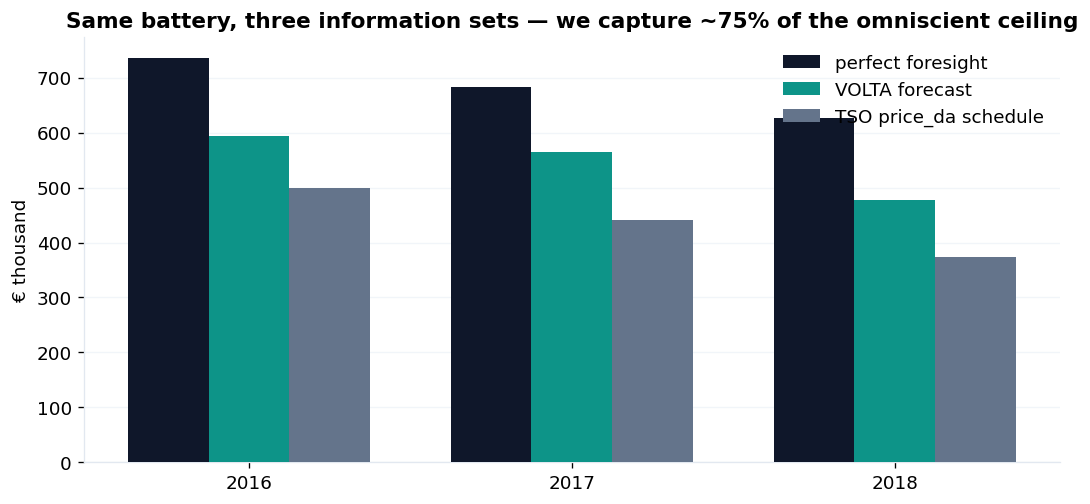

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
years = [2016, 2017, 2018]
x = np.arange(len(years))
w = 0.25
ax.bar(x - w, cmp.loc[years, "perfect"]/1e3, w, color=NAVY, label="perfect foresight", zorder=3)
ax.bar(x, cmp.loc[years, "VOLTA forecast"]/1e3, w, color=TEAL, label="VOLTA forecast", zorder=3)
ax.bar(x + w, cmp.loc[years, "TSO price_da"]/1e3, w, color=SLATE, label="TSO price_da schedule", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel("€ thousand")
ax.set_title("Same battery, three information sets — we capture ~75% of the omniscient ceiling")
ax.legend()
ax.set_axisbelow(True)
ax.xaxis.grid(False)
savefig(fig, "23_perfect_vs_realistic.png")
plt.show()


**Insight.** On 2016–18 the omniscient battery prints the ceiling. Scheduling on VOLTA's forecast keeps **about three quarters** of that. Scheduling on the TSO's `price_da` keeps less. The gap is the *cost of forecast error* — and it is also why Phase 2 existed. A better price model is not a Kaggle flex; it is euros the optimizer cannot recover any other way.


---
## Asset economics (be honest)

Four-year mean perfect-foresight profit is on the order of **€0.6–1.1m / year**.

2018-era turnkey Li-ion is assumed at **€350/kWh** → 200 MWh × €350,000 = **€70m** capex. WACC 7%, 15-year life.

That battery does **not** pay back on 2015–18 Spanish spreads. Saying otherwise would be the kind of README lie recruiters smell. The honest claim is: *this is what the spread was worth; here is the capex at which it would clear.*


In [9]:
annual_perfect = perfect["profit_eur"].sum() / 4
annual_real = realistic["profit_eur"].sum() / 3   # 2016-18
econ_p = economics(annual_perfect)
econ_r = economics(annual_real)
econ_tbl = pd.DataFrame([econ_p, econ_r], index=["perfect (4y avg)", "VOLTA realistic (2016-18 avg)"])
display(econ_tbl[["capex_eur", "annual_profit_eur", "payback_years", "npv_eur"]].T)

# capex breakeven: payback = life  →  capex = annual * life  (undiscounted, ballpark)
print("undiscounted breakeven €/kWh (perfect): {:.0f}".format(
    annual_perfect * ASSET_LIFE_YEARS / (DEFAULT_BATTERY.capacity_mwh * 1000)
))
print("NPV-zero €/kWh (perfect, 7% WACC): {:.0f}".format(
    annual_perfect * econ_p["annuity_factor"] / (DEFAULT_BATTERY.capacity_mwh * 1000)
))


,perfect (4y avg),VOLTA realistic (2016-18 avg)
capex_eur,"70,000,000.00","70,000,000.00"
annual_profit_eur,"783,570.99","545,577.34"
payback_years,89.33,128.30
npv_eur,"-62,863,302.83","-65,030,928.48"


undiscounted breakeven €/kWh (perfect): 59
NPV-zero €/kWh (perfect, 7% WACC): 36


saved notebooks/figures/24_sensitivity.png


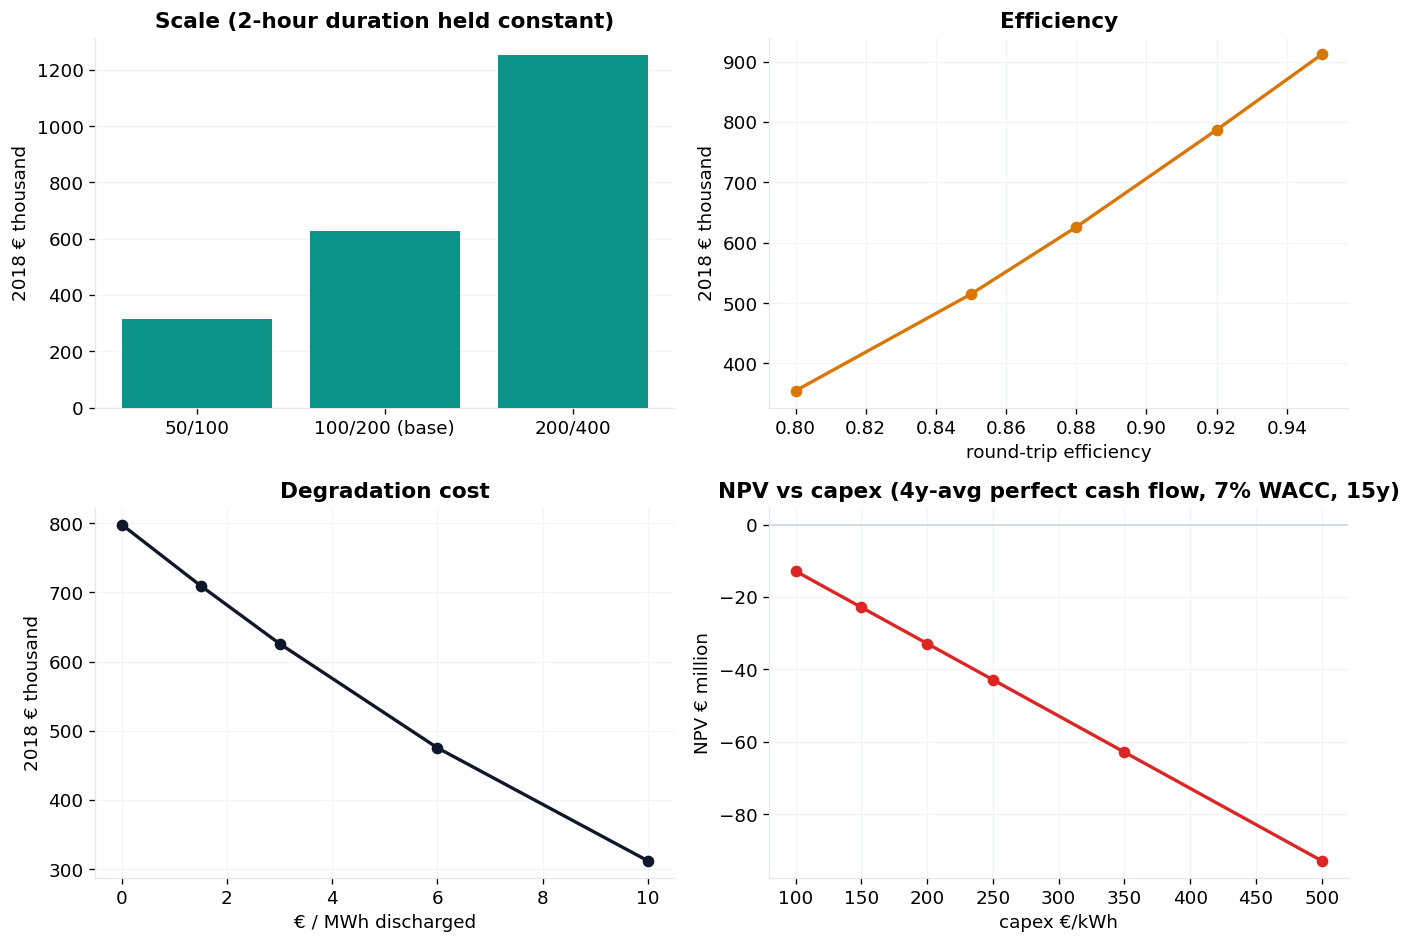

,power_mw,capacity_mwh,profit_2018
0,50,100,"313,016.52"
1,100,200,"626,033.04"
2,200,400,"1,252,066.08"


,round_trip,profit_2018
0,0.80,"354,846.01"
1,0.85,"514,951.86"
2,0.88,"626,033.04"
3,0.92,"786,894.97"
4,0.95,"912,005.33"


,degradation_eur_per_mwh,profit_2018
0,0.00,"798,211.82"
1,1.50,"709,789.81"
2,3.00,"626,033.04"
3,6.00,"475,370.85"
4,10.00,"311,998.52"


In [10]:
# Sensitivity: 2018 perfect P&L vs size / efficiency / degradation, then NPV vs capex.
spot_2018 = spot.loc["2018"]

def year_profit(**kw):
    d, _ = backtest_daily(spot_2018, battery=with_battery(**kw))
    return d["profit_eur"].sum()

sizes = pd.DataFrame([
    {"power_mw": 50, "capacity_mwh": 100},
    {"power_mw": 100, "capacity_mwh": 200},
    {"power_mw": 200, "capacity_mwh": 400},
])
sizes["profit_2018"] = [year_profit(power_mw=r.power_mw, capacity_mwh=r.capacity_mwh) for r in sizes.itertuples()]

effs = pd.DataFrame({"round_trip": [0.80, 0.85, 0.88, 0.92, 0.95]})
effs["profit_2018"] = [year_profit(round_trip=x) for x in effs["round_trip"]]

degs = pd.DataFrame({"degradation_eur_per_mwh": [0.0, 1.5, 3.0, 6.0, 10.0]})
degs["profit_2018"] = [year_profit(degradation_eur_per_mwh=x) for x in degs["degradation_eur_per_mwh"]]

capex_grid = np.array([100, 150, 200, 250, 350, 500])
npvs = [economics(annual_perfect, capex_eur_per_kwh=float(c))["npv_eur"] / 1e6 for c in capex_grid]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))
axes[0, 0].bar(["50/100", "100/200 (base)", "200/400"], sizes["profit_2018"]/1e3, color=TEAL, zorder=3)
axes[0, 0].set_ylabel("2018 € thousand")
axes[0, 0].set_title("Scale (2-hour duration held constant)")
axes[0, 0].xaxis.grid(False)

axes[0, 1].plot(effs["round_trip"], effs["profit_2018"]/1e3, color=AMBER, marker="o", lw=2)
axes[0, 1].set_xlabel("round-trip efficiency")
axes[0, 1].set_ylabel("2018 € thousand")
axes[0, 1].set_title("Efficiency")

axes[1, 0].plot(degs["degradation_eur_per_mwh"], degs["profit_2018"]/1e3, color=NAVY, marker="o", lw=2)
axes[1, 0].set_xlabel("€ / MWh discharged")
axes[1, 0].set_ylabel("2018 € thousand")
axes[1, 0].set_title("Degradation cost")

axes[1, 1].axhline(0, color="#CBD5E1", lw=1)
axes[1, 1].plot(capex_grid, npvs, color=RED, marker="o", lw=2)
axes[1, 1].set_xlabel("capex €/kWh")
axes[1, 1].set_ylabel("NPV € million")
axes[1, 1].set_title("NPV vs capex (4y-avg perfect cash flow, 7% WACC, 15y)")
fig.tight_layout()
savefig(fig, "24_sensitivity.png")
plt.show()
display(sizes)
display(effs)
display(degs)


**Insight.** P&L scales almost linearly with energy at 2-hour duration (the cycle cap is the binding constraint, not power). Efficiency is a bigger lever than degradation in this range. **NPV is negative at any capex this asset actually cost in 2018.** It flips positive somewhere around the *undiscounted* €/kWh printed above — pack prices that did not exist then, and that the duck-curve of 2015–18 (solar stuck at 5%) did not justify. The trading desk is still the right model; the *market* just was not ready to pay for this battery yet.


In [11]:
# Persist daily P&L for Phase 4 / the app. (copy to drop the hourly attrs blob)
cols = ["profit_eur", "cash_eur", "mwh_discharge", "spread_eur", "cycles"]
perfect[cols].assign(policy="perfect").to_parquet(CACHE / "dispatch_perfect_daily.parquet")
realistic[cols].assign(policy="volta").to_parquet(CACHE / "dispatch_volta_daily.parquet")
tso_bt[cols].assign(policy="tso").to_parquet(CACHE / "dispatch_tso_daily.parquet")
hourly_p.to_parquet(CACHE / "dispatch_hourly_perfect.parquet")
print("wrote cache/dispatch_*_daily.parquet  perfect days", len(perfect))


wrote cache/dispatch_*_daily.parquet  perfect days 1461


---
## Checkpoint

| Item | Status |
|---|---|
| LP | `src/optimizer.py` — linprog/HiGHS, cyclic, 1 cycle/day, €3/MWh deg |
| Invariants | `tests/test_optimizer.py` — SOC, power, energy balance, DST 23/25h |
| Ceiling | ~€0.6–1.1m / year perfect foresight, **€3.1m over 2015–18** |
| Realistic | VOLTA forecast keeps ~75% of the 2016–18 ceiling; TSO schedule less |
| Cost of forecast error | the perfect−VOLTA gap (the reason Phase 2 exists) |
| Economics | **NPV-negative at 2018 capex (€350/kWh)** — stated, not dressed up |
| Artifacts | `cache/dispatch_daily.parquet`, `cache/wf_forecasts_2016_2018.parquet` |

**Assumptions we owe an interviewer**

1. η_c = η_d = √0.88.
2. Degradation = €3 / MWh *discharged to the grid* (not both-way throughput).
3. 1 cycle/day cap is a warranty stand-in, not a physics limit.
4. Cyclic SOC: every day ends where it started. No multi-day energy shifting.
5. Capex €350/kWh is 2018-era turnkey, not 2024 cells.
6. Realistic forecasts start 2016 — 2015 has no honest walk-forward.

Next: Phase 4 — CHARGE / DISCHARGE / HOLD cards with a why, from this schedule + quantile spread.


In [12]:
print("=" * 60)
print("VOLTA · 03 dispatch checkpoint")
print("=" * 60)
print("perfect 2015-18 total  €{:,.0f}".format(perfect["profit_eur"].sum()))
print("perfect mean year      €{:,.0f}".format(annual_perfect))
print("VOLTA 2016-18 total    €{:,.0f}".format(realistic["profit_eur"].sum()))
print("TSO    2016-18 total   €{:,.0f}".format(tso_bt["profit_eur"].sum()))
print("payback perfect        {:.1f} years  (capex €{:.0f}m)".format(
    econ_p["payback_years"], econ_p["capex_eur"]/1e6,
))
print("NPV perfect            €{:,.1f}m".format(econ_p["npv_eur"]/1e6))
print("done.")


VOLTA · 03 dispatch checkpoint
perfect 2015-18 total  €3,134,284
perfect mean year      €783,571
VOLTA 2016-18 total    €1,636,732
TSO    2016-18 total   €1,314,317
payback perfect        89.3 years  (capex €70m)
NPV perfect            €-62.9m
done.
